In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, make_circles, make_swiss_roll
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [23]:
# Dataset 1: Moons
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

In [13]:
# Dataset 2: Blobs
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=42)

In [8]:
# Circles
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

In [9]:
# Swiss Roll
X, _ = make_swiss_roll(n_samples=300, noise=0.05, random_state=42)

In [24]:
# Scale the data
X = StandardScaler().fit_transform(X)

In [37]:
# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=10)
labels = dbscan.fit_predict(X)

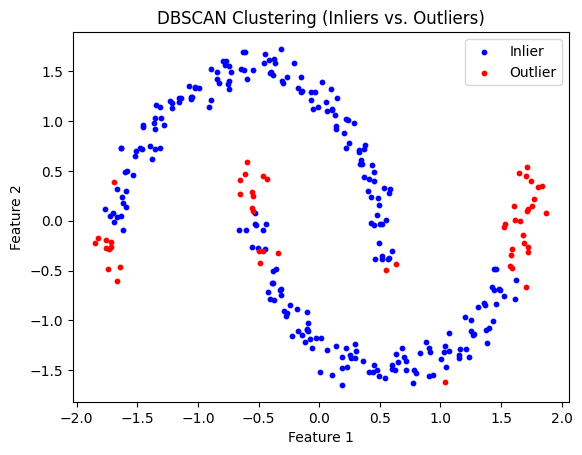

In [39]:
# Step 3: Visualize the results
# Unique labels and colors for each cluster
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
# Plot clustered points (inliers) in blue
inlier_mask = (labels != -1)
plt.scatter(X[inlier_mask, 0], X[inlier_mask, 1], c='blue', label='Inlier', s=10)

# Plot noise points (outliers) in red
outlier_mask = (labels == -1)
plt.scatter(X[outlier_mask, 0], X[outlier_mask, 1], c='red', label='Outlier', s=10)

plt.title('DBSCAN Clustering (Inliers vs. Outliers)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

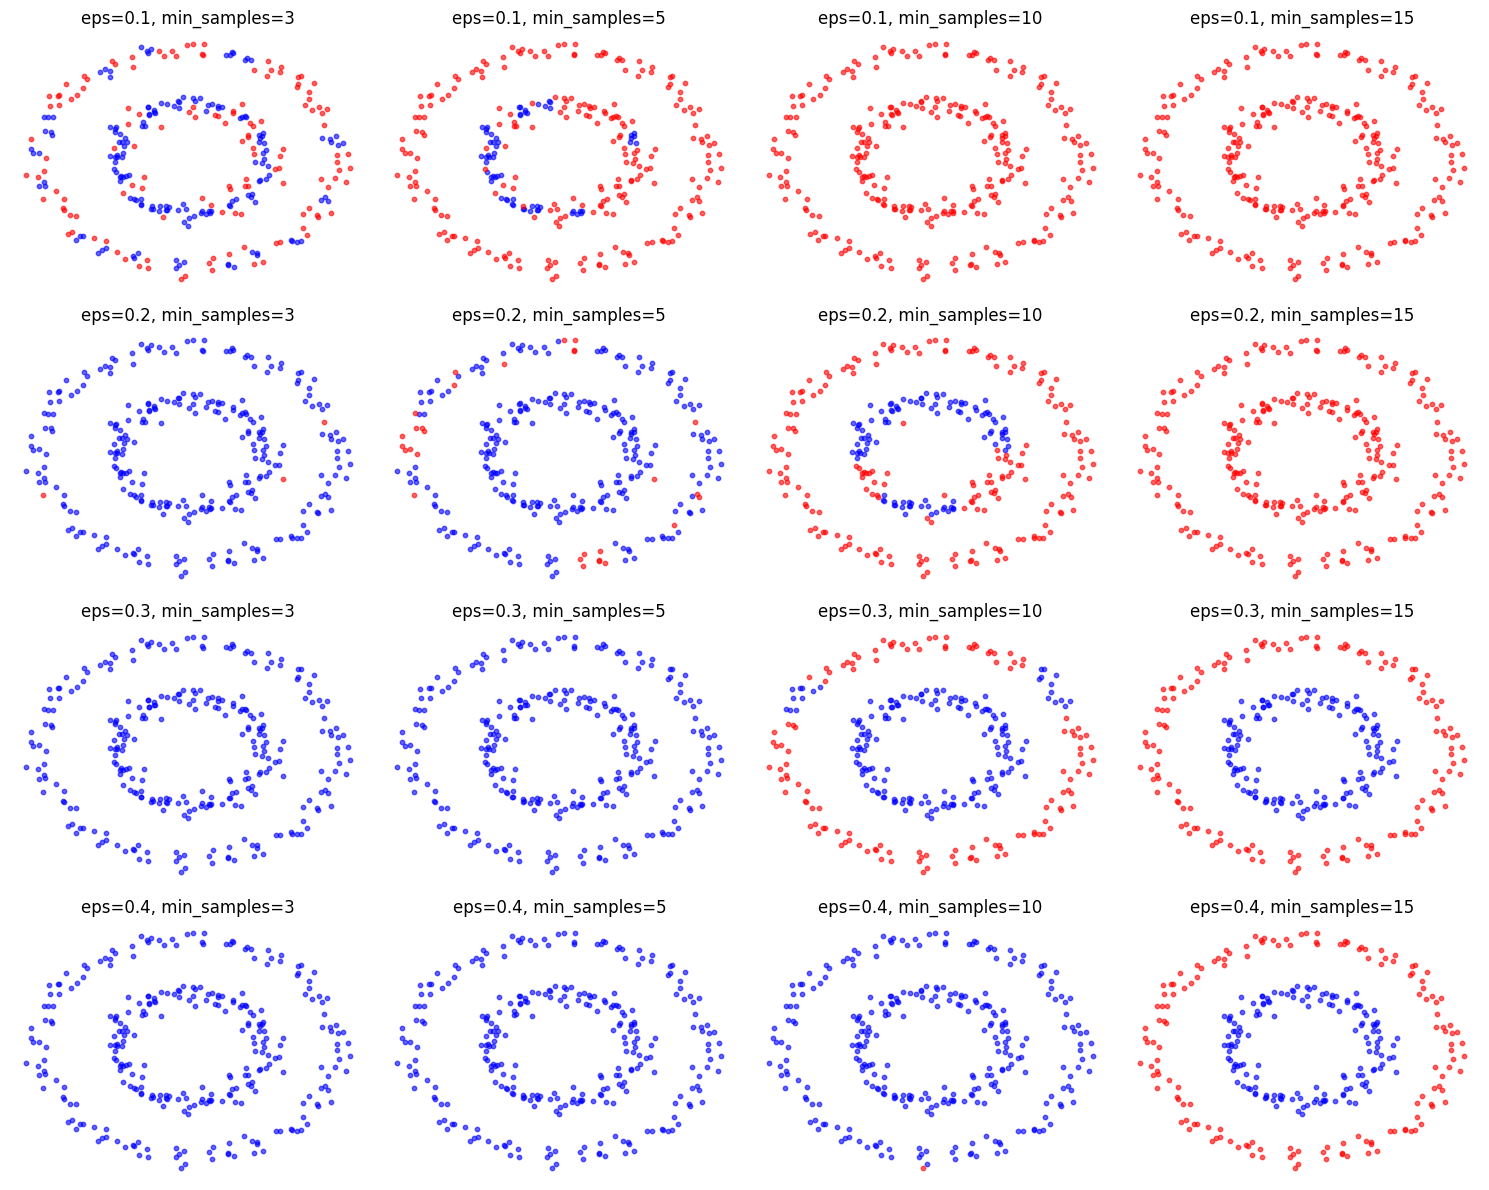

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Generate synthetic data (Circles dataset)
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X = StandardScaler().fit_transform(X)

# Define parameter combinations for eps and min_samples
eps_values = [0.1, 0.2, 0.3, 0.4]
min_samples_values = [3, 5, 10, 15]

# Create a grid of subplots
fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(15, 12), sharex=True, sharey=True)

# Loop through each combination of eps and min_samples
for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # Plot clustered points in blue, noise points in red with reduced alpha
        ax = axes[i, j]
        inlier_mask = (labels != -1)
        outlier_mask = (labels == -1)
        
        ax.scatter(X[inlier_mask, 0], X[inlier_mask, 1], c='blue', s=10, alpha=0.6, label='Inlier')
        ax.scatter(X[outlier_mask, 0], X[outlier_mask, 1], c='red', s=10, alpha=0.6, label='Outlier')
        
        # Add a border around each plot
        ax.set_facecolor('white')
        ax.spines['top'].set_linewidth(1.5)
        ax.spines['right'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

        ax.set_title(f'eps={eps}, min_samples={min_samples}')
        ax.axis('off')

plt.tight_layout()
plt.show

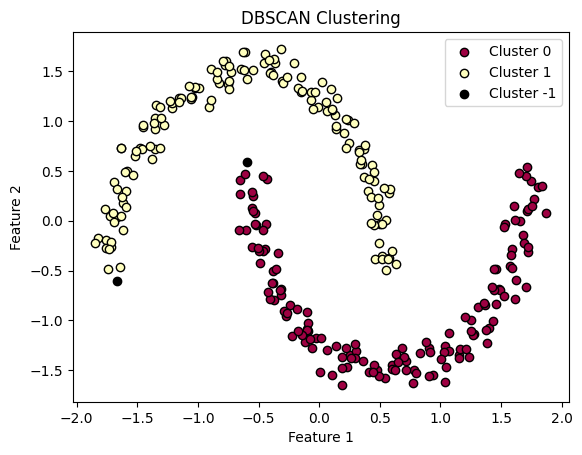

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic data
# Uncomment one of the following datasets to use

# Dataset 1: Moons
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Dataset 2: Blobs
# X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=42)

# Scale the data
X = StandardScaler().fit_transform(X)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
labels = dbscan.fit_predict(X)

# Step 3: Visualize the results
# Unique labels and colors for each cluster
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

# Plot each cluster
for label, color in zip(unique_labels, colors):
    if label == -1:
        # Black color for noise
        color = [0, 0, 0, 1]
    
    mask = (labels == label)
    plt.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Cluster {label}', edgecolor='k')

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [49]:
labels

array([ 0,  0,  0,  1,  0,  0,  0,  1,  1,  0,  0,  1,  0,  1,  0,  0,  0,
        0,  1,  0,  1,  1,  0,  0,  1,  1,  0,  0,  0,  0,  1,  0,  1,  1,
        0,  1,  1,  1,  1,  1,  1,  1,  0,  1,  1,  1,  0,  0,  1,  0,  0,
        1,  0,  1,  0,  0,  1,  1,  0,  1,  0,  1,  1,  0,  0,  1,  1,  0,
        1,  0,  1,  1,  0,  0,  1,  0,  1,  1,  1,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  0, -1,  0,  1,  0,  1,
        1,  0,  0,  0,  1,  1,  0,  1,  1,  0,  1,  0,  0,  1,  1,  0,  0,
        0,  1,  0,  0,  0,  1,  0,  1,  1,  0,  0,  1,  1,  0,  1,  0,  0,
        0,  0,  0,  1,  1,  1,  0,  1,  0,  0,  1,  1,  1,  1,  0,  1,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  0,  1,  1,  1,  1,  0,  0,  0,  1,
        1,  0,  0,  1,  1,  0,  1,  1,  0,  1,  0,  1,  0,  0,  1,  0,  0,
        0,  1,  1,  1, -1,  0,  0,  0,  1,  0,  0,  1,  0,  1,  1,  1,  0,
        0,  0,  0,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  0,  0,  1,  1,
        0,  0,  0,  1,  0